# PHÂN NHÓM SINH VIÊN THEO HỒ SƠ SỨC KHỎE TÂM THẦN
## *High Risk – Moderate Stress – Resilient*

## 0. Cài đặt thư viện

In [1]:
# CÀI ĐẶT THƯ VIỆN (chạy lần đầu nếu chưa cài)
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy yellowbrick plotly

## 1. Import thư viện & Cấu hình

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

# Xử lý dữ liệu
import pandas as pd
import numpy as np

# Trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Tiền xử lý
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Thuật toán phân cụm
from sklearn.cluster import KMeans, AgglomerativeClustering

# Đánh giá
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import cdist

# Phân tích thống kê
from scipy.cluster.hierarchy import dendrogram, linkage

# Cấu hình hiển thị
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Tất cả thư viện đã được import thành công!')

✅ Tất cả thư viện đã được import thành công!


## 2. Tải dữ liệu

In [3]:
DATA_PATH = './data/Student_Depression_Dataset.csv'  # Chỉnh lại nếu cần

df_raw = pd.read_csv(DATA_PATH)
print(f'📌 Số lượng mẫu  : {df_raw.shape[0]:,} sinh viên')
print(f'📌 Số thuộc tính : {df_raw.shape[1]} cột')
print()
print('5 hàng đầu tiên:')
df_raw.head()

📌 Số lượng mẫu  : 27,901 sinh viên
📌 Số thuộc tính : 18 cột

5 hàng đầu tiên:


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0000,Visakhapatnam,Student,5.0000,0.0000,8.9700,2.0000,0.0000,5-6 hours,Healthy,B.Pharm,Yes,3.0000,1.0000,No,1
1,8,Female,24.0000,Bangalore,Student,2.0000,0.0000,5.9000,5.0000,0.0000,5-6 hours,Moderate,BSc,No,3.0000,2.0000,Yes,0
2,26,Male,31.0000,Srinagar,Student,3.0000,0.0000,7.0300,5.0000,0.0000,Less than 5 hours,Healthy,BA,No,9.0000,1.0000,Yes,0
3,30,Female,28.0000,Varanasi,Student,3.0000,0.0000,5.5900,2.0000,0.0000,7-8 hours,Moderate,BCA,Yes,4.0000,5.0000,Yes,1
4,32,Female,25.0000,Jaipur,Student,4.0000,0.0000,8.1300,3.0000,0.0000,5-6 hours,Moderate,M.Tech,Yes,1.0000,1.0000,No,0


## 3. Tiền xử lý dữ liệu

In [4]:
df = df_raw.copy()

# --- Mã hóa Sleep Duration (ordinal) ---
sleep_map = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4
}
df['Sleep_Score'] = df['Sleep Duration'].map(sleep_map).fillna(2)

# --- Mã hóa Dietary Habits (ordinal) ---
diet_map = {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3}
df['Diet_Score'] = df['Dietary Habits'].map(diet_map).fillna(2)

# --- Mã hóa nhị phân ---
df['Suicidal_Thoughts'] = df['Have you ever had suicidal thoughts ?'].map({'Yes': 1, 'No': 0}).fillna(0)
df['Family_History']    = df['Family History of Mental Illness'].map({'Yes': 1, 'No': 0}).fillna(0)
df['Gender_Code']       = df['Gender'].map({'Male': 0, 'Female': 1}).fillna(0)

nominal_cols = ['City', 'Degree', 'Profession']
le_dict = {}
for c in nominal_cols:
    le = LabelEncoder()
    df[c + ' Enc'] = le.fit_transform(df[c].astype(str))
    le_dict[c] = le
    print(f"✅ LabelEncoder {c}: {len(le.classes_)} nhãn")

✅ LabelEncoder City: 52 nhãn
✅ LabelEncoder Degree: 28 nhãn
✅ LabelEncoder Profession: 14 nhãn


## 4. Khai thác dữ liệu
### 4.1 Tạo thuộc tính mới

In [ ]:
df['Total_Pressure'] = (df['Academic Pressure'].fillna(0) + 
                        df['Work Pressure'].fillna(0) + 
                        df['Financial Stress'].fillna(0))

df['Wellbeing_Score'] = (df['Study Satisfaction'].fillna(0) +
                         df['Job Satisfaction'].fillna(0) +
                         df['Sleep_Score'] +
                         df['Diet_Score'] +
                         df['CGPA'].fillna(0) / 2)  # chuẩn hóa CGPA

df['Stress_Index'] = (0.35 * df['Academic Pressure'] + 0.40 * df['Financial Stress'] + 0.25 * df['Work Pressure'])

df['Lifestyle_Index'] = (df['Sleep_Score'] + df['Diet_Score'] + df['Study Satisfaction']) / 3

df['Pressure_per_Hour'] = (df['Total_Pressure'] / (df['Work/Study Hours'] + 1))

df['Mental_Risk_Score'] = (df['Stress_Index'] + df['Suicidal_Thoughts'] * 2 - df['Lifestyle_Index'])

ALL_FEATURES = [
    'Stress_Index',        # tổng hợp áp lực (|corr|=0.545)
    'Lifestyle_Index',     # chất lượng sống (|corr|=0.251)
    'Mental_Risk_Score',   # tổng hợp rủi ro (|corr|=0.675) ← cao nhất
    'Suicidal_Thoughts',   # 0/1 chỉ báo nguy cơ (|corr|=0.546)
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress',
    # Biến đã mã hóa
    'Sleep_Score', 'Diet_Score',
    'Gender_Code', 'Family_History',
    'City Enc', 'Degree Enc', 'Profession Enc'
]

### 4.2 Lựa chọn thuộc tính

In [ ]:
# Mức độ quan trọng của các đặc trưng (dựa trên |corr|^1.5 + 0.02)
corr_with_depression = df[ALL_FEATURES + ['Depression']].corr()['Depression'].abs()
feature_weights = (corr_with_depression[ALL_FEATURES] ** 1.5 + 0.02).values

print('📊 Feature Weights (corr^1.5 + 0.02):')
for feat, w_val, c in sorted(
        zip(ALL_FEATURES, feature_weights, corr_with_depression[ALL_FEATURES].values),
        key=lambda x: -x[1]):
    bar = '█' * int(w_val * 35)
    print(f'  {feat:25s}: weight={w_val:.4f}  (|corr|={c:.3f})  {bar}')

📊 Feature Weights (corr^1.5 + 0.02):
  Mental_Risk_Score        : weight=0.5742  (|corr|=0.675)  ████████████████████
  Suicidal_Thoughts        : weight=0.4238  (|corr|=0.546)  ██████████████
  Stress_Index             : weight=0.4219  (|corr|=0.545)  ██████████████
  Academic Pressure        : weight=0.3472  (|corr|=0.475)  ████████████
  Financial Stress         : weight=0.2392  (|corr|=0.364)  ████████
  Lifestyle_Index          : weight=0.1456  (|corr|=0.251)  █████
  Age                      : weight=0.1277  (|corr|=0.226)  ████
  Work/Study Hours         : weight=0.1152  (|corr|=0.209)  ████
  Diet_Score               : weight=0.1139  (|corr|=0.207)  ███
  Study Satisfaction       : weight=0.0888  (|corr|=0.168)  ███
  Sleep_Score              : weight=0.0457  (|corr|=0.087)  █
  Family_History           : weight=0.0324  (|corr|=0.053)  █
  City Enc                 : weight=0.0239  (|corr|=0.025)  
  CGPA                     : weight=0.0233  (|corr|=0.022)  
  Profession Enc    

In [7]:
FEATURES = [
    'Stress_Index',        # tổng hợp áp lực (|corr|=0.545)
    'Lifestyle_Index',     # chất lượng sống (|corr|=0.251)
    'Mental_Risk_Score',   # tổng hợp rủi ro (|corr|=0.675) ← cao nhất
    'Suicidal_Thoughts',   # 0/1 chỉ báo nguy cơ (|corr|=0.546)
]

X = df[FEATURES].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Điền giá trị khuyết bằng trung vị
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Chuẩn hóa (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Feature Weighting — dùng corr^1.5 + 0.02
corr_with_depression = df[FEATURES + ['Depression']].corr()['Depression'].abs()
feature_weights = (corr_with_depression[FEATURES] ** 1.5 + 0.02).values

print('📊 Feature Weights (corr^1.5 + 0.02):')
for feat, w_val, c in sorted(
        zip(FEATURES, feature_weights, corr_with_depression[FEATURES].values),
        key=lambda x: -x[1]):
    bar = '█' * int(w_val * 35)
    print(f'  {feat:25s}: weight={w_val:.4f}  (|corr|={c:.3f})  {bar}')

X_weighted = X_scaled * feature_weights

📊 Feature Weights (corr^1.5 + 0.02):
  Mental_Risk_Score        : weight=0.5742  (|corr|=0.675)  ████████████████████
  Suicidal_Thoughts        : weight=0.4238  (|corr|=0.546)  ██████████████
  Stress_Index             : weight=0.4219  (|corr|=0.545)  ██████████████
  Lifestyle_Index          : weight=0.1456  (|corr|=0.251)  █████


### 4.3 Giảm chiều dữ liệu (PCA)

In [8]:
N_COMPONENTS = 2
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_final = pca.fit_transform(X_weighted)

cumvar = pca.explained_variance_ratio_.cumsum()
print(f'PCA ({N_COMPONENTS} components) giải thích: {cumvar[-1]*100:.1f}% phương sai')
for i, (var, cumv) in enumerate(zip(pca.explained_variance_ratio_, cumvar)):
    print(f'   PC{i+1}: {var*100:.1f}%  (tích lũy: {cumv*100:.1f}%)')

PCA (2 components) giải thích: 94.5% phương sai
   PC1: 77.0%  (tích lũy: 77.0%)
   PC2: 17.5%  (tích lũy: 94.5%)


### 4.4 Thuật toán K-Means

In [9]:
K_range = range(2, 11)
inertias        = []
silhouette_scores = []
db_scores       = []
ch_scores       = []

print('Đang tính toán K-Means trên X_final (weighted + PCA)...')
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)  # n_init=20
    labels = km.fit_predict(X_final)                                           # X_final thay vì X_scaled
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_final, labels, sample_size=3000, random_state=42))
    db_scores.append(davies_bouldin_score(X_final, labels))
    ch_scores.append(calinski_harabasz_score(X_final, labels))
    print(f'  K={k}: Inertia={km.inertia_:.0f}, Silhouette={silhouette_scores[-1]:.4f}')

print('\n✅ Hoàn thành!')

Đang tính toán K-Means trên X_final (weighted + PCA)...
  K=2: Inertia=7288, Silhouette=0.5539
  K=3: Inertia=4450, Silhouette=0.5053
  K=4: Inertia=2692, Silhouette=0.5139
  K=5: Inertia=1929, Silhouette=0.4763
  K=6: Inertia=1473, Silhouette=0.4621
  K=7: Inertia=1176, Silhouette=0.4436
  K=8: Inertia=998, Silhouette=0.4366
  K=9: Inertia=852, Silhouette=0.4198
  K=10: Inertia=770, Silhouette=0.4019

✅ Hoàn thành!


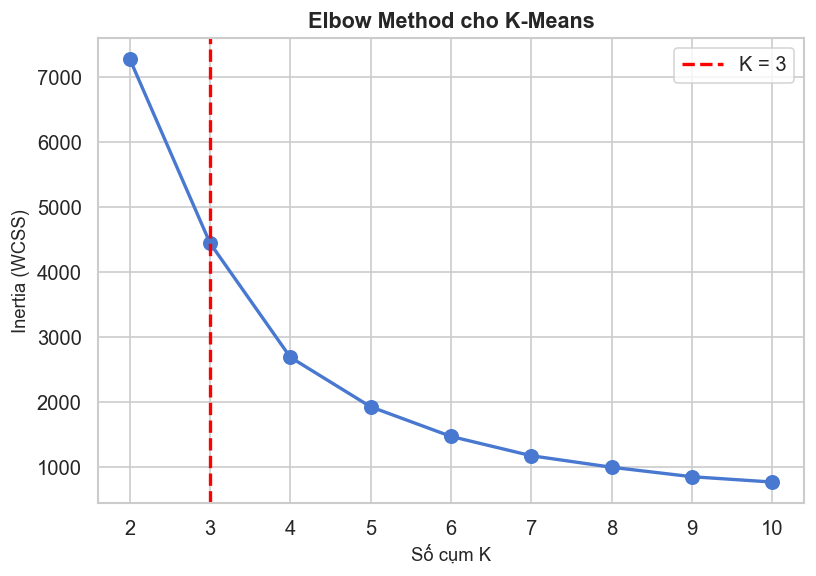

 → Chọn K = 3


In [10]:
# ============================================================
# ELBOW METHOD — XÁC ĐỊNH K TỐI ƯU CHO K-MEANS
# ============================================================

plt.figure(figsize=(7, 5))
K_list = list(K_range)
plt.plot(K_list, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', linewidth=2, label='K = 3')
plt.title('Elbow Method cho K-Means', fontsize=13, fontweight='bold')
plt.xlabel('Số cụm K', fontsize=11)
plt.ylabel('Inertia (WCSS)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()
print(' → Chọn K = 3')

In [11]:
K_OPTIMAL = 3

kmeans_final = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=20, max_iter=500, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_final)

# Gán nhãn ý nghĩa dựa vào mức áp lực trung bình
cluster_pressure = pd.Series(kmeans_labels).to_frame('cluster').assign(
    pressure=df['Total_Pressure'].values).groupby('cluster')['pressure'].mean()

rank = cluster_pressure.rank()
label_map = {}
for cid in cluster_pressure.index:
    r = rank[cid]
    if r == 3:   label_map[cid] = 'high_risk'
    elif r == 2: label_map[cid] = 'moderate_stress'
    else:        label_map[cid] = 'resilient'

df['KMeans_Cluster'] = kmeans_labels
df['KMeans_Label']   = pd.Series(kmeans_labels).map(label_map).values
print('\nGán nhãn:', label_map)
print(df['KMeans_Label'].value_counts())


Gán nhãn: {0: 'high_risk', 1: 'moderate_stress', 2: 'resilient'}
KMeans_Label
high_risk          10529
moderate_stress     9703
resilient           7669
Name: count, dtype: int64


### 4.5 Thuật toán HAC

Đang xây dựng Hierarchical Clustering...


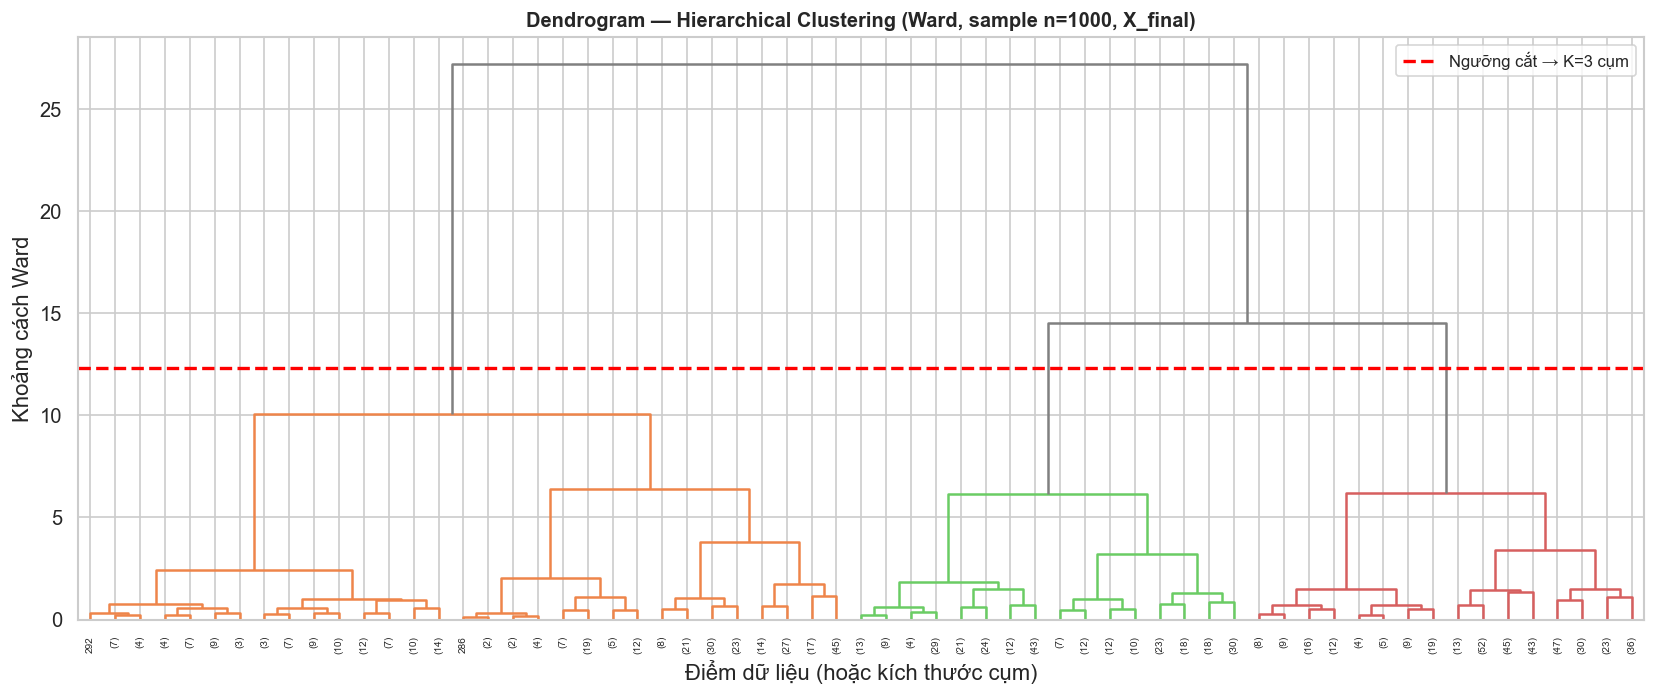

In [12]:
print('Đang xây dựng Hierarchical Clustering...')
# Dendrogram trên sample (Hierarchical tốn bộ nhớ với full dataset)
sample_idx = np.random.choice(len(X_final), 1000, replace=False)
X_sample   = X_final[sample_idx]

Z = linkage(X_sample, method='ward')
cut_threshold = (Z[-2, 2] + Z[-3, 2]) / 2

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           color_threshold=cut_threshold,
           above_threshold_color='gray')
ax.set_title('Dendrogram — Hierarchical Clustering (Ward, sample n=1000, X_final)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Điểm dữ liệu (hoặc kích thước cụm)')
ax.set_ylabel('Khoảng cách Ward')

ax.axhline(y=cut_threshold, color='red', linestyle='--', linewidth=2, 
           label='Ngưỡng cắt → K=3 cụm')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# Áp dụng Agglomerative Clustering toàn bộ dữ liệu
print('Đang chạy Agglomerative Clustering trên toàn bộ dữ liệu...')
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_final)                         # X_final

sil_hc = silhouette_score(X_final, agg_labels, sample_size=5000, random_state=42)
print(f'\nHierarchical (Ward, K=3) trên X_final:')
print(f'  Silhouette: {sil_hc:.4f}')
print(f'  Phân phối :', pd.Series(agg_labels).value_counts().to_dict())

# Gán nhãn ý nghĩa
hc_pressure = pd.Series(agg_labels).to_frame('cluster').assign(
    pressure=df['Total_Pressure'].values).groupby('cluster')['pressure'].mean().rank()

hc_label_map = {}
for cid in hc_pressure.index:
    r = hc_pressure[cid]
    if r == 3:   hc_label_map[cid] = 'high_risk'
    elif r == 2: hc_label_map[cid] = 'moderate_stress'
    else:        hc_label_map[cid] = 'resilient'

df['Hierarchical_Cluster'] = agg_labels
df['Hierarchical_Label']   = pd.Series(agg_labels).map(hc_label_map).values

Đang chạy Agglomerative Clustering trên toàn bộ dữ liệu...

Hierarchical (Ward, K=3) trên X_final:
  Silhouette: 0.4697
  Phân phối : {1: 10624, 0: 10245, 2: 7032}


### 4.6 Đánh giá mô hình

In [14]:
def dunns_index(X, labels):
    unique_labels = [l for l in set(labels) if l != -1]
    if len(unique_labels) < 2:
        return np.nan
    sample_size = min(2000, len(X))
    idx = np.random.choice(len(X), sample_size, replace=False)
    X_s, labels_s = X[idx], labels[idx]
    inter_dists = []
    for i in range(len(unique_labels)):
        for j in range(i+1, len(unique_labels)):
            ci = X_s[labels_s == unique_labels[i]]
            cj = X_s[labels_s == unique_labels[j]]
            if len(ci) > 0 and len(cj) > 0:
                inter_dists.append(cdist(ci, cj).min())
    intra_diams = []
    for lbl in unique_labels:
        ci = X_s[labels_s == lbl]
        if len(ci) > 1:
            intra_diams.append(cdist(ci, ci).max())
    if not inter_dists or not intra_diams:
        return np.nan
    return min(inter_dists) / max(intra_diams)

np.random.seed(42)
di_kmeans = dunns_index(X_final, kmeans_labels)
di_hc     = dunns_index(X_final, agg_labels)

print("Dunn's Index:")
print(f'  K-Means      : {di_kmeans:.4f}')
print(f'  Hierarchical : {di_hc:.4f}')


Dunn's Index:
  K-Means      : 0.0154
  Hierarchical : 0.0244


In [15]:
sil_km = silhouette_score(X_final, kmeans_labels, sample_size=5000, random_state=42)
sil_hc = silhouette_score(X_final, agg_labels,   sample_size=5000, random_state=42)

db_km = davies_bouldin_score(X_final, kmeans_labels)
db_hc = davies_bouldin_score(X_final, agg_labels)

ch_km = calinski_harabasz_score(X_final, kmeans_labels)
ch_hc = calinski_harabasz_score(X_final, agg_labels)

results_df = pd.DataFrame({
    'Thuật toán': ['K-Means (K=3)', 'Hierarchical (Ward, K=3)'],
    'Số cụm': [3, 3],
    'Silhouette Score ↑': [round(sil_km, 4), round(sil_hc, 4)],
    'Davies-Bouldin ↓':   [round(db_km, 4), round(db_hc, 4)],
    "Dunn's Index ↑":     [round(di_kmeans, 4), round(di_hc, 4)],
    'Calinski-Harabasz ↑':[round(ch_km, 0), round(ch_hc, 0)],
})
display(results_df.set_index('Thuật toán'))

print('📌 Chú thích:')
print('   Silhouette  : [-1, 1], càng cao càng tốt (> 0.5 = tốt)')
print('   Davies-Bouldin: [0,∞), càng thấp càng tốt')
print("   Dunn's Index : (0,∞), càng cao càng tốt")
print('   Calinski-Harabasz: càng cao càng tốt')


,Số cụm,Silhouette Score ↑,Davies-Bouldin ↓,Dunn's Index ↑,Calinski-Harabasz ↑
Thuật toán,,,,,
K-Means (K=3),3,0.5030,0.6794,0.0154,44619.0000
"Hierarchical (Ward, K=3)",3,0.4697,0.6848,0.0244,39236.0000


📌 Chú thích:
   Silhouette  : [-1, 1], càng cao càng tốt (> 0.5 = tốt)
   Davies-Bouldin: [0,∞), càng thấp càng tốt
   Dunn's Index : (0,∞), càng cao càng tốt
   Calinski-Harabasz: càng cao càng tốt


### 4.7 Kết quả huấn luyện

In [16]:
print('=' * 70)
print('PHÂN TÍCH ĐẶC ĐIỂM TỪNG NHÓM SINH VIÊN (K-MEANS, K=3)')
print('=' * 70)

for label in ['high_risk', 'moderate_stress', 'resilient']:
    subset = df[df['KMeans_Label'] == label]
    n = len(subset)
    print(f'\nNhóm: {label.upper()} (n={n:,}, {n/len(df)*100:.1f}%)')

PHÂN TÍCH ĐẶC ĐIỂM TỪNG NHÓM SINH VIÊN (K-MEANS, K=3)

Nhóm: HIGH_RISK (n=10,529, 37.7%)

Nhóm: MODERATE_STRESS (n=9,703, 34.8%)

Nhóm: RESILIENT (n=7,669, 27.5%)


### 4.8 Xuất dữ liệu kết quả

In [17]:
output_cols = list(df_raw.columns) + [
    'Sleep_Score', 'Diet_Score', 'Suicidal_Thoughts', 'Family_History',
    'Total_Pressure', 'Wellbeing_Score',
    'Stress_Index', 'Lifestyle_Index', 'Mental_Risk_Score',
    'KMeans_Cluster', 'KMeans_Label',
    'Hierarchical_Cluster', 'Hierarchical_Label',
]

output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(
    output_dir,
    'student_mental_health_clustered.csv'
)

df_output = df[[c for c in output_cols if c in df.columns]]
df_output.to_csv(output_path, index=False)
print('Đã xuất kết quả phân cụm ra file: student_mental_health_clustered.csv')
print(f'   Kích thước: {df_output.shape}')
print('Phân phối nhóm cuối cùng (K-Means):')
print(df_output['KMeans_Label'].value_counts())


Đã xuất kết quả phân cụm ra file: student_mental_health_clustered.csv
   Kích thước: (27901, 31)
Phân phối nhóm cuối cùng (K-Means):
KMeans_Label
high_risk          10529
moderate_stress     9703
resilient           7669
Name: count, dtype: int64
